# The resource-consumer NP model with odeint

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [2]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [3]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


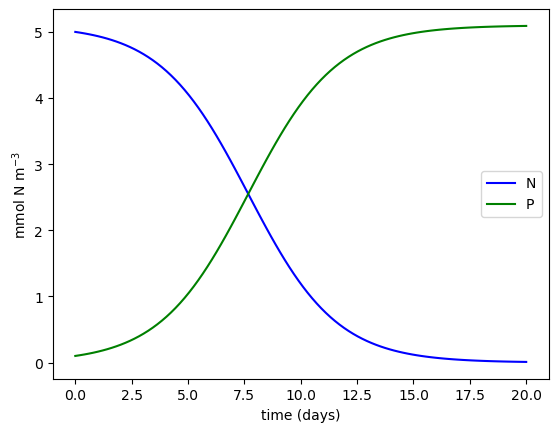

In [5]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise

### Question 1: Inputs and Outputs of the function model

AI was used to help identify the inputs and outputs. Below is the summary of my understanding.

Inputs
- state (a vector/array containing the current nutrient and phytoplankton concentrations) -> state = [N, P]
- t (current time, float)
- k (rate constant, float)

Outputs
- Array containing the derivatives of P and N, [dN/dt, dP/dt]

Odeint uses the derivatives to integrate the system of differential equations through time.

### Question 2
Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

### Diagram of the Nutrient-Phytoplpankton-Detritus Model

PARAMETERS
- k = 0.1      → nutrient uptake / rate of phytoplankton growth
- m = 0.05    → mortality / rate of phytoplankton lysis
- r = 0.02     → rate of remineralization 

INITIAL CONDITIONS
- N0 = 5.0    → mmol N m^-3 Nutrient concentration
- P0 = 0.1     → mmol N m^-3 Phytoplankton concentration
- D0 = 0.0     → mmol N m^-3 Detritus concentration

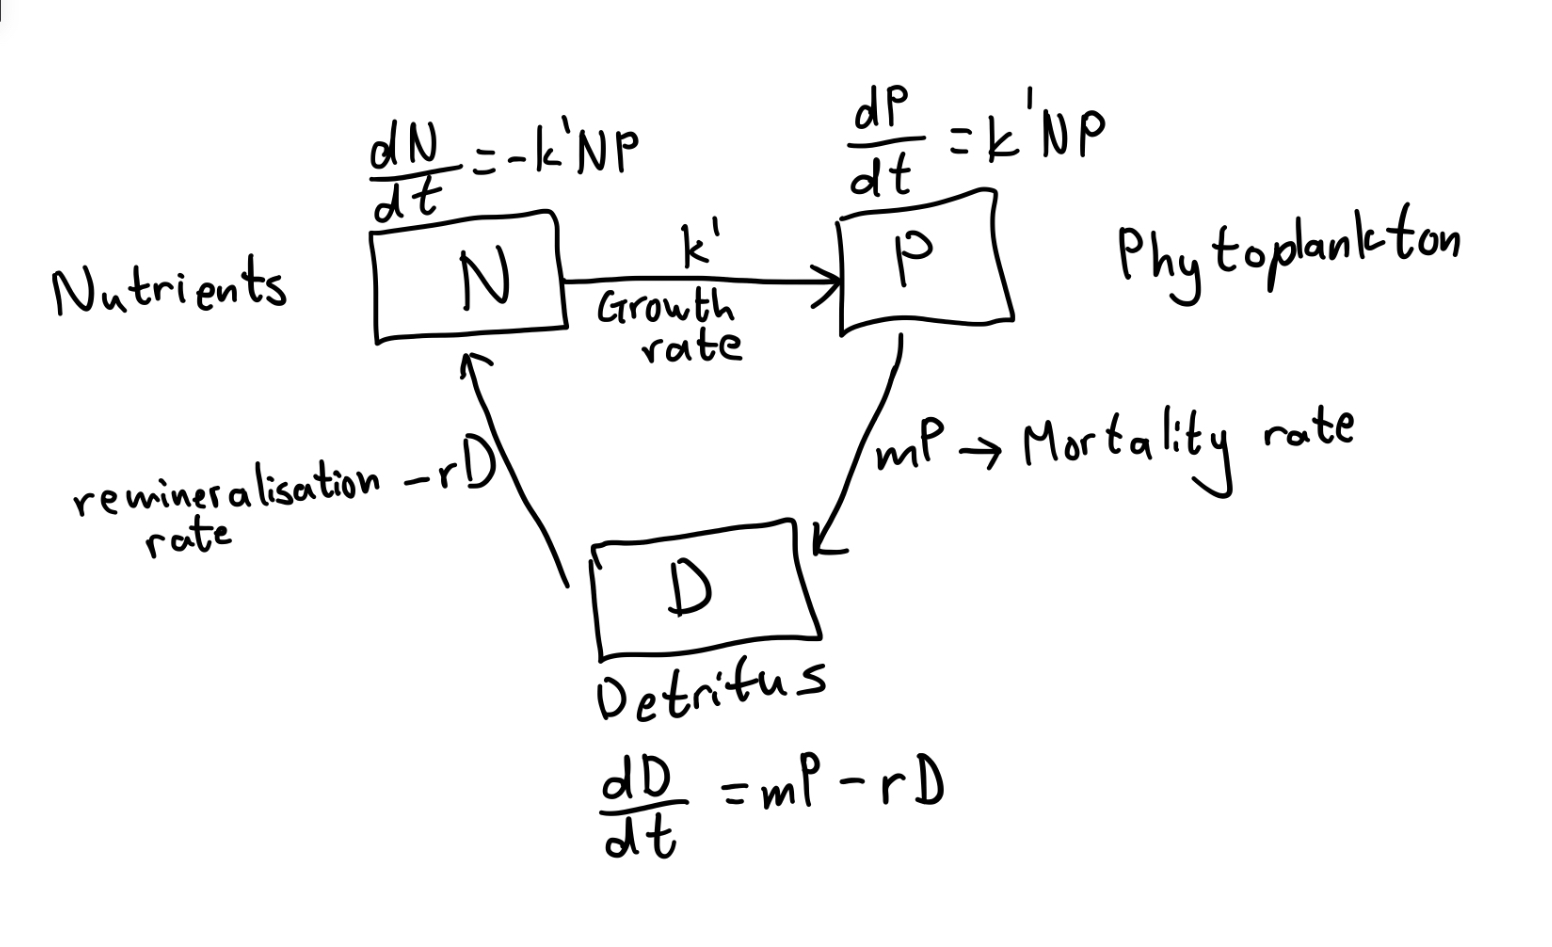

*AI prompted with exercise question

#### Nutrient–Phytoplankton–Detritus (NPD) Model

#### Step 1: Start with the NP model

The original nutrient–phytoplankton model is:

$$
\frac{dN}{dt} = -kNP
$$

$$
\frac{dP}{dt} = kNP
$$

where:

- $N$ = nutrient concentration
- $P$ = phytoplankton concentration
- $k$ = phytoplankton growth rate

---

#### Step 2: Introduce detritus

A new state variable is added:

$$
D = \text{detritus concentration}
$$

Two new processes are included.

<u>Phytoplankton mortality</u>

Dead phytoplankton become detritus:

$$
P \rightarrow D
$$

with mortality rate:

$$
mP
$$

where:

- $m$ = phytoplankton mortality rate (day$^{-1}$)

<u>Remineralization</u>

Detritus is converted back into nutrients:

$$
D \rightarrow N
$$

with remineralization rate:

$$
rD
$$

where:

- $r$ = remineralization rate (day$^{-1}$)

---

#### Step 3: Derive the governing equations

<u> Nutrients</u>

Nutrients are consumed by phytoplankton growth and produced by remineralization:

$$
\frac{dN}{dt}
=
-kNP + rD
$$

<u> Phytoplankton</u>

Phytoplankton increase through nutrient uptake and decrease through mortality:

$$
\frac{dP}{dt}
=
kNP - mP
$$

<u> Detritus </u>

Detritus is produced by mortality and lost through remineralization:

$$
\frac{dD}{dt}
=
mP - rD
$$

---

#### Final NPD Model

$$
\frac{dN}{dt}
=
-kNP + rD
$$

$$
\frac{dP}{dt}
=
kNP - mP
$$

$$
\frac{dD}{dt}
=
mP - rD
$$

---

#### Mass Conservation

Adding the three equations gives:

$$
\frac{d}{dt}(N+P+D)=0
$$

which shows that total nitrogen is conserved within the system.

#### Variables and Parameters

- $N$ = nutrient concentration
- $P$ = phytoplankton concentration
- $D$ = detritus concentration
- $k$ = phytoplankton growth rate
- $m$ = phytoplankton mortality rate
- $r$ = remineralization rate

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

* AI prompted with the exercise question

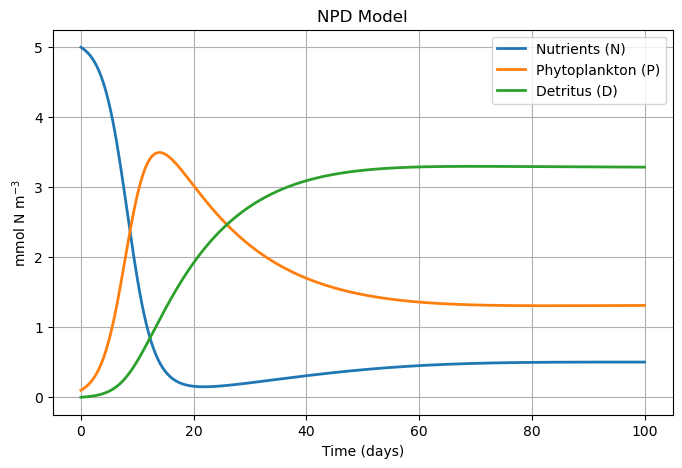

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --------------------------------------------------
# NPD MODEL
# --------------------------------------------------

def model(state, t, k, m, r):

    N, P, D = state

    dNdt = -k * N * P + r * D

    dPdt =  k * N * P - m * P

    dDdt =  m * P - r * D

    return np.array([dNdt, dPdt, dDdt])

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------

k = 0.1      # nutrient uptake
m = 0.05     # mortality
r = 0.02     # remineralization

# --------------------------------------------------
# INITIAL CONDITIONS
# --------------------------------------------------

N0 = 5.0     # mmol N m^-3
P0 = 0.1     # mmol N m^-3
D0 = 0.0     # mmol N m^-3

state0 = np.array([N0, P0, D0])

# --------------------------------------------------
# TIME VECTOR
# --------------------------------------------------

t = np.linspace(0, 100, 500)

# --------------------------------------------------
# SOLVE ODE SYSTEM
# --------------------------------------------------

y = odeint(model, state0, t, args=(k, m, r))

N = y[:,0]
P = y[:,1]
D = y[:,2]

# --------------------------------------------------
# PLOT RESULTS
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(t, N, label='Nutrients (N)', linewidth=2)
plt.plot(t, P, label='Phytoplankton (P)', linewidth=2)
plt.plot(t, D, label='Detritus (D)', linewidth=2)

plt.xlabel('Time (days)')
plt.ylabel('mmol N m$^{-3}$')

plt.title('NPD Model')

plt.legend()
plt.grid()

plt.show()


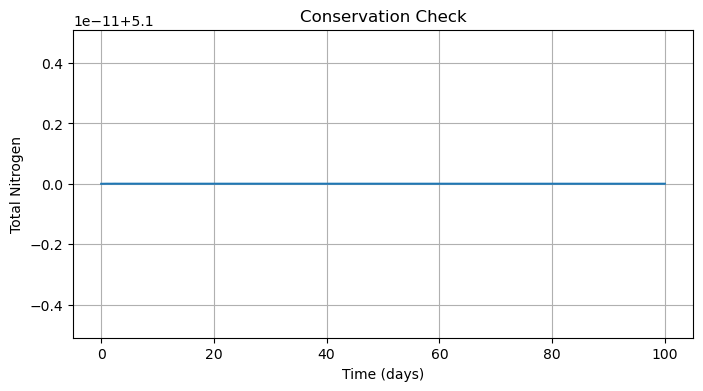

Initial total N = 5.1
Final total N   = 5.100000000000002


In [9]:
total_N = N + P + D

plt.figure(figsize=(8,4))
plt.plot(t, total_N)

plt.xlabel('Time (days)')
plt.ylabel('Total Nitrogen')

plt.title('Conservation Check')
plt.grid()

plt.show()

print('Initial total N =', total_N[0])
print('Final total N   =', total_N[-1])